<a href="https://colab.research.google.com/github/hosein-ald/git_test/blob/main/scRNA_PBMC_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scanpy

In [2]:
!pip install anndata

In [3]:
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
adata=sc.datasets.pbmc3k()

In [5]:
adata.var

,gene_ids
index,
MIR1302-10,ENSG00000243485
FAM138A,ENSG00000237613
OR4F5,ENSG00000186092
RP11-34P13.7,ENSG00000238009
RP11-34P13.8,ENSG00000239945
...,...
AC145205.1,ENSG00000215635
BAGE5,ENSG00000268590
CU459201.1,ENSG00000251180


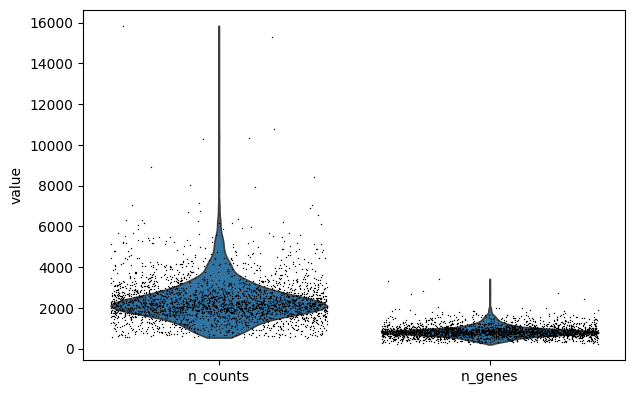

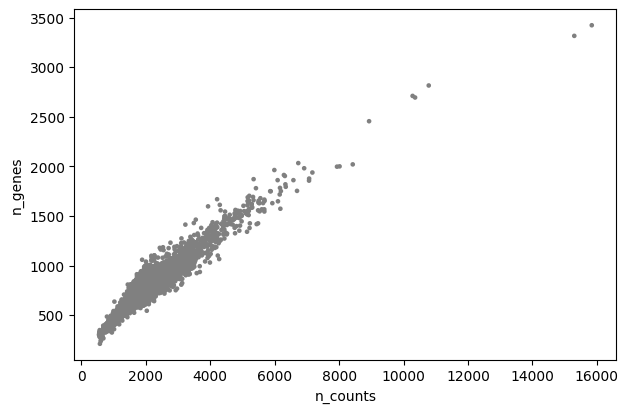

In [6]:
# Calculate QC metrics
adata.obs['n_counts'] = adata.X.sum(axis=1).A1
adata.obs['n_genes'] = (adata.X > 0).sum(axis=1).A1
adata.var['n_cells'] = (adata.X > 0).sum(axis=0).A1

# Plot QC metrics
sc.pl.violin(adata, ['n_counts', 'n_genes'], jitter=0.4)
sc.pl.scatter(adata, x='n_counts', y='n_genes')

# Filter cells and genes
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)


In [7]:
adata.var_names_make_unique()  # Ensure gene names are unique

# Calculate QC metrics
adata.var["mt"] = adata.var_names.str.startswith("MT-")  # Mark mitochondrial genes
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

# View summary statistics
adata.obs[["total_counts", "n_genes_by_counts", "pct_counts_mt"]].describe()



,total_counts,n_genes_by_counts,pct_counts_mt
count,2700.000000,2700.000000,2700.000000
mean,2365.376953,845.546667,2.216642
std,1093.379028,281.347923,1.166707
min,546.000000,212.000000,0.000000
25%,1755.750000,690.000000,1.537264
50%,2196.000000,816.000000,2.030800
75%,2762.250000,952.000000,2.643177
max,15818.000000,3400.000000,22.569027


In [8]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)


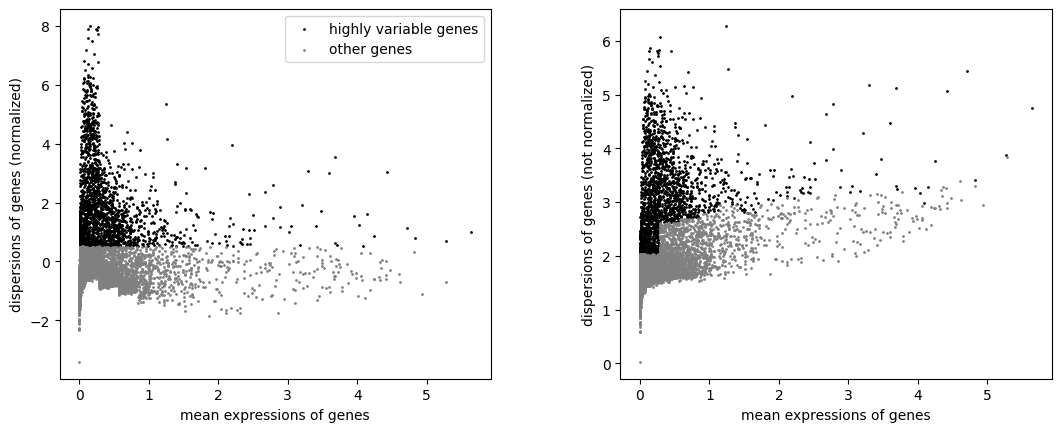

In [9]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
#adata = adata[:, adata.var['highly_variable']]
sc.pl.highly_variable_genes(adata)



In [10]:
sc.pp.scale(adata, max_value=10)


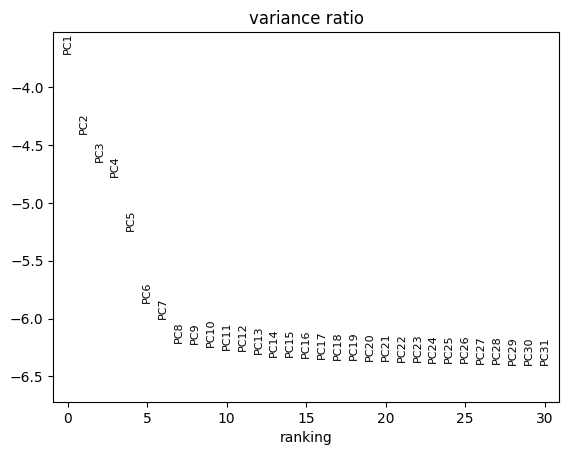

In [11]:
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True)

In [12]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)



In [13]:
#!pip install leidenalg
#import os
#os._exit(00)
!pip install leidenalg


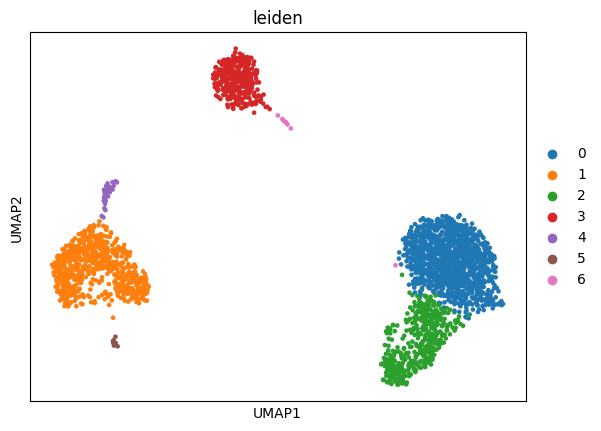

In [16]:
sc.tl.leiden(adata, resolution=0.5)
sc.tl.umap(adata)
sc.pl.umap(adata, color=['leiden'])

/usr/local/lib/python3.11/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.11/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.11/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.11/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.11/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.11/dist-packages/scanpy/tools/_rank_genes_groups.py:455: 

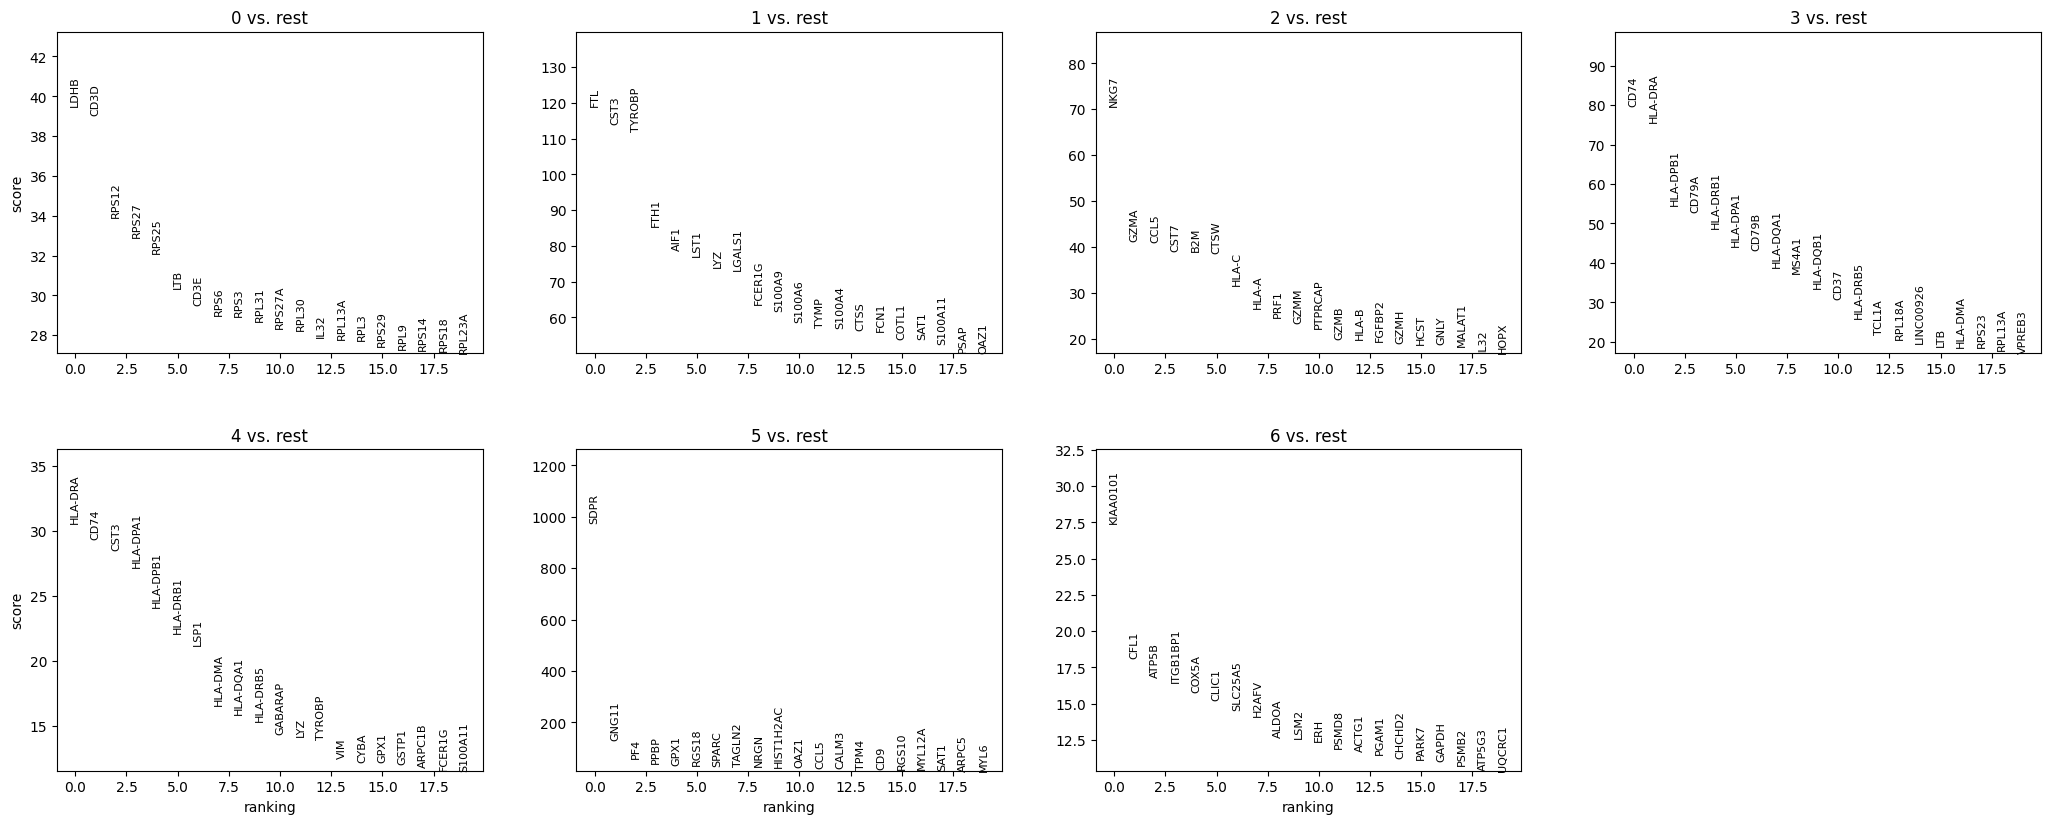

In [17]:
sc.tl.rank_genes_groups(adata, 'leiden', method='t-test')
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

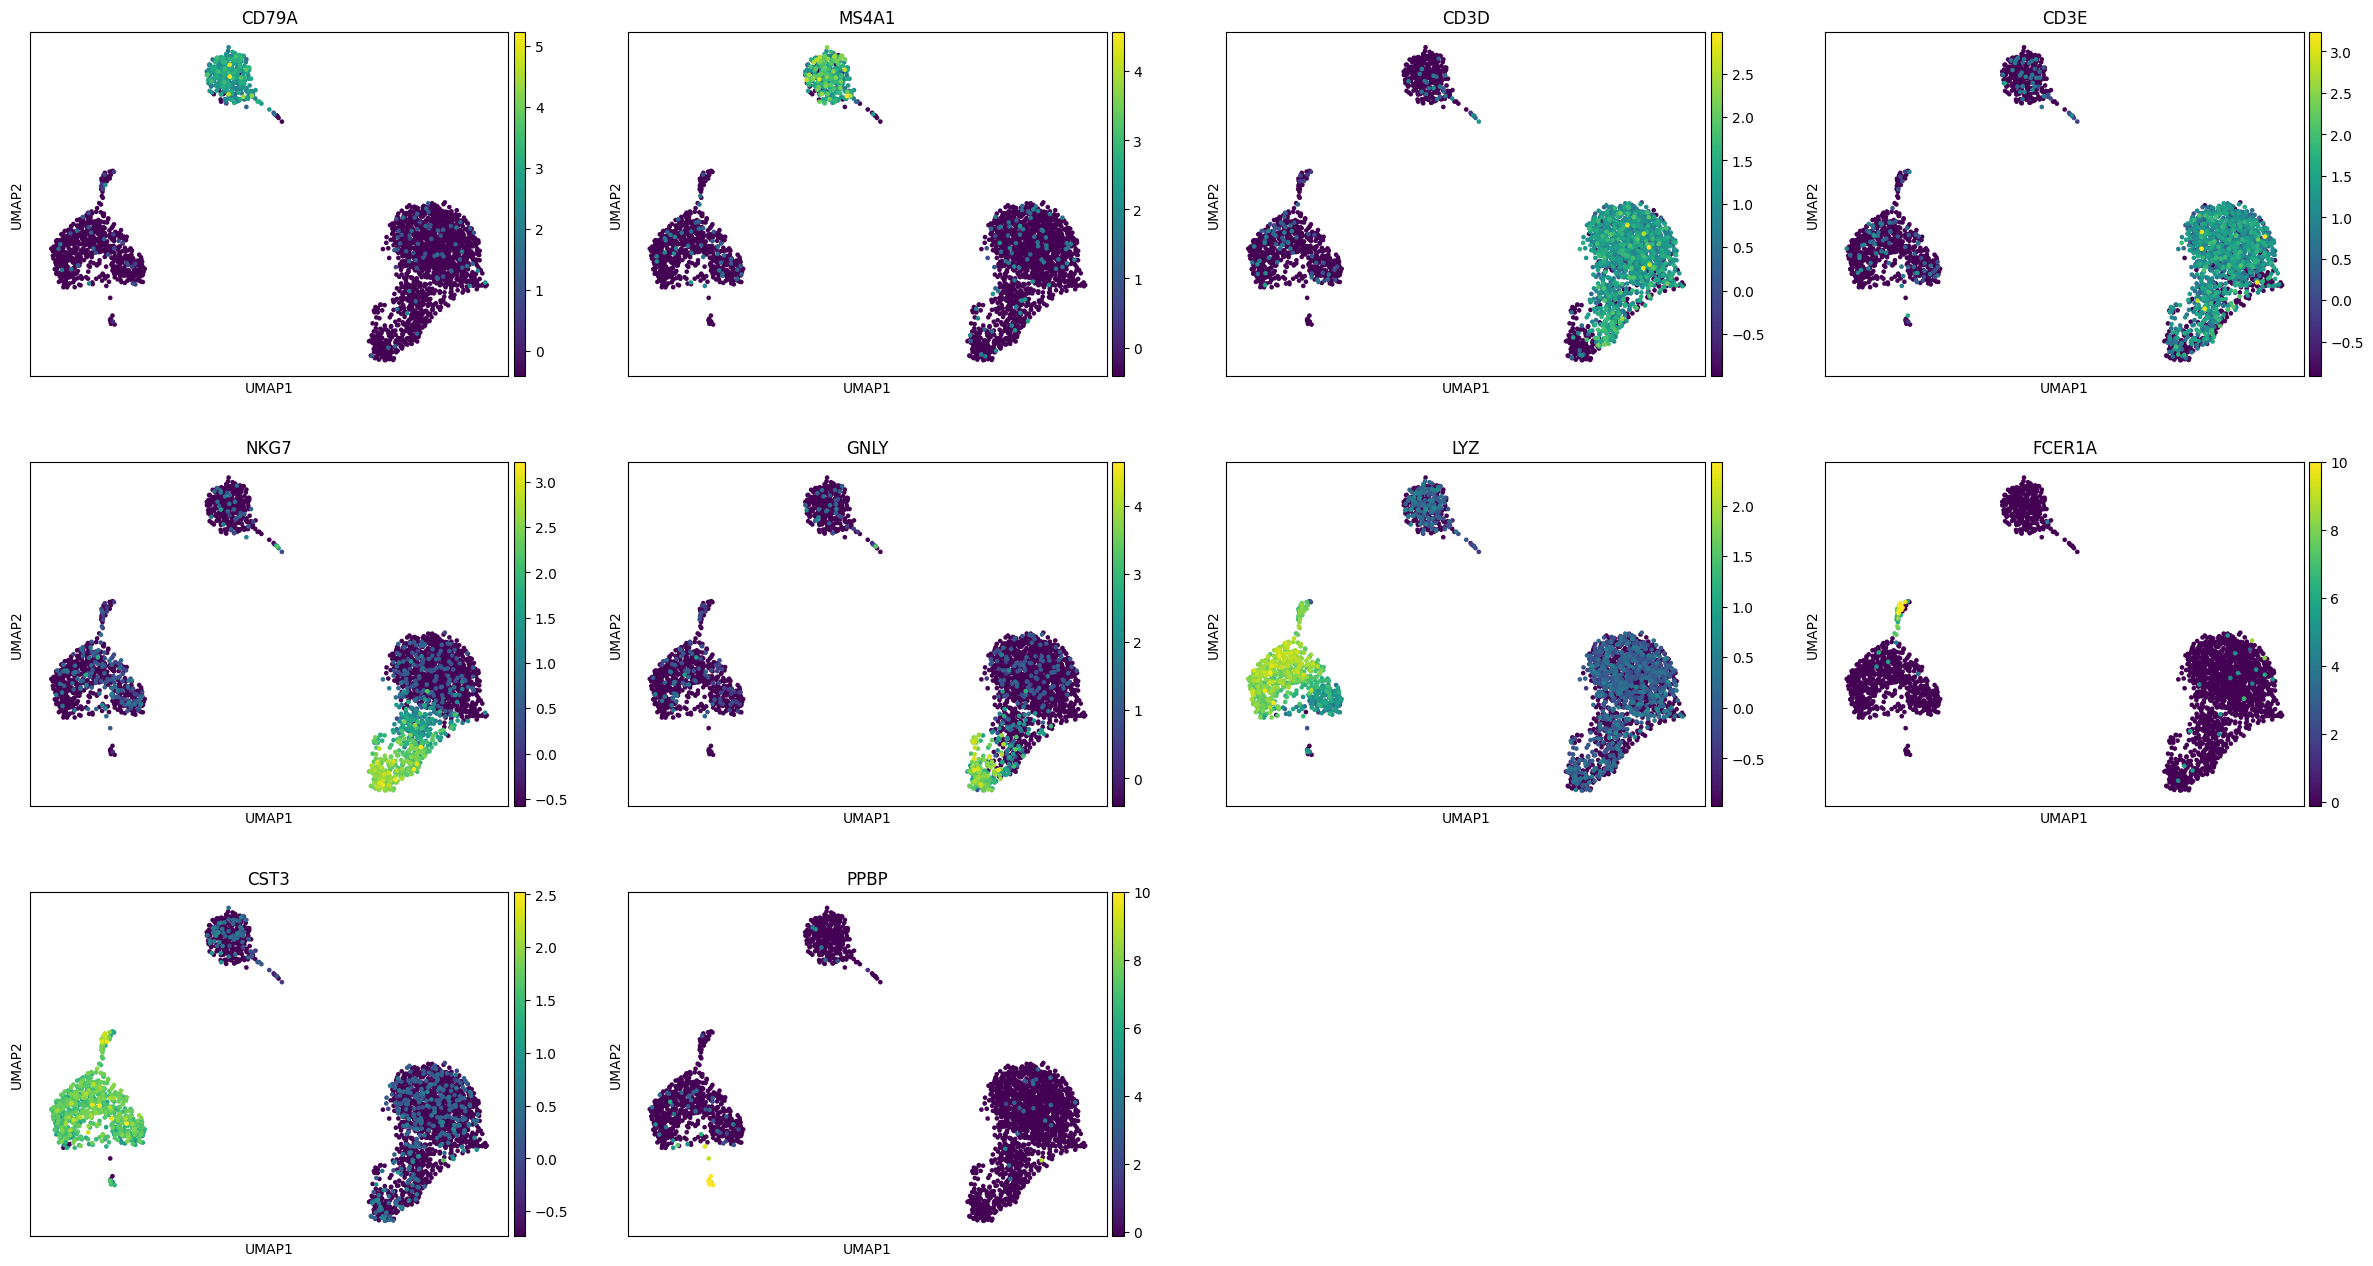

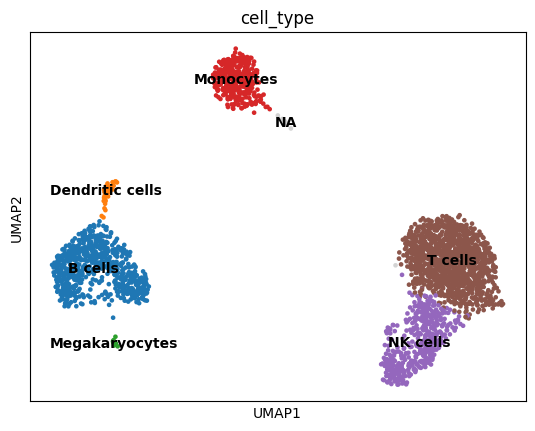

In [18]:
marker_genes = {
    'B cells': ['CD79A', 'MS4A1'],
    'T cells': ['CD3D', 'CD3E'],
    'NK cells': ['NKG7', 'GNLY'],
    'Monocytes': ['LYZ'],
    'Dendritic cells': ['FCER1A', 'CST3'],
    'Megakaryocytes': ['PPBP']
}

# Plot marker genes on UMAP
sc.pl.umap(adata, color=[gene for genes in marker_genes.values() for gene in genes])

# Assign cell type annotations
# This is a simplified example; in practice, you may use more sophisticated methods
adata.obs['cell_type'] = adata.obs['leiden'].map({
    '0': 'T cells',
    '1': 'B cells',
    '2': 'NK cells',
    '3': 'Monocytes',
    '4': 'Dendritic cells',
    '5': 'Megakaryocytes'
})
sc.pl.umap(adata, color='cell_type', legend_loc='on data')

/usr/local/lib/python3.11/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


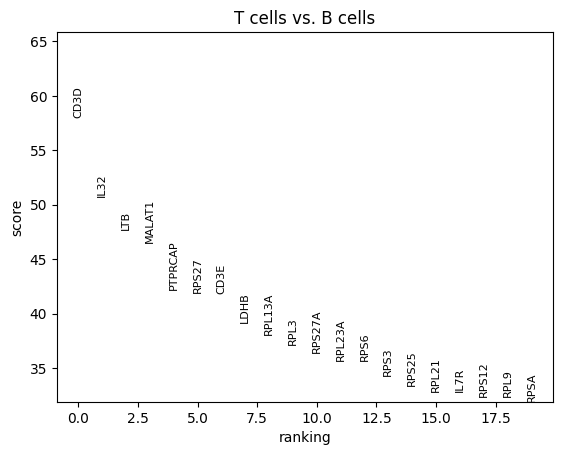

In [20]:
sc.tl.rank_genes_groups(adata, 'cell_type', groups=['T cells'], reference='B cells', method='t-test')
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)